# Credit Card Default – Exploratory Data Analysis (EDA)
### การสำรวจข้อมูลเบื้องต้น: ใครผิดนัดชำระหนี้บัตรเครดิต และเพราะอะไร

**Goal:** understand which customers default on their credit card debt, before building a model.

**Data:** ISLR `Default` dataset – 10,000 simulated customers, cleaned by `01_cleaning.py`.

| Column | Type | Meaning |
|---|---|---|
| `default_flag` | categorical (0/1) | **Target** – 1 = customer defaulted |
| `is_student` | categorical (0/1) | 1 = customer is a student |
| `balance` | quantitative | Average card balance left after monthly payment |
| `income` | quantitative | Customer income |

**Tools:** SQL (DuckDB) for the summary tables, Python (pandas, seaborn) for the charts.
SQL queries come from `sql/02_eda.sql` – each result below shows the query that produced it.

## Guide / คู่มือการอ่าน

**English**
- **What this notebook does:** explores the clean data to find *who* defaults and *why*, before any model is built.
- **Input:** `data/default_clean.csv` (made by `01_cleaning.ipynb`).
- **Outputs:** a table under each SQL query, and 7 charts saved in `outputs/figures/` (`01_…` to `07_…`).
- **Read it in 3 minutes:** skip the code. Look at each chart and its **How to read** note, then read **Section 8 – Summary**.

**ภาษาไทย**
- **Notebook นี้ทำอะไร:** สำรวจข้อมูลที่ทำความสะอาดแล้ว เพื่อหาว่า *ใคร* ผิดนัดชำระหนี้ และ *เพราะอะไร* ก่อนสร้างโมเดล
- **ข้อมูลเข้า:** `data/default_clean.csv` (สร้างจาก `01_cleaning.ipynb`)
- **ผลลัพธ์:** ตารางใต้คำสั่ง SQL แต่ละอัน และกราฟ 7 รูปใน `outputs/figures/` (`01_…` ถึง `07_…`)
- **อ่านจบใน 3 นาที:** ข้ามโค้ดได้เลย ดูกราฟแต่ละรูปพร้อมคำอธิบาย **วิธีอ่าน** แล้วอ่าน **หัวข้อ 8 – สรุป**

**Key words / คำสำคัญ:** default = ผิดนัดชำระหนี้ (ไม่จ่ายหนี้บัตร) · balance = ยอดหนี้คงค้างบนบัตร · income = รายได้ · student = นักศึกษา

| Figure / กราฟ | Shows / แสดงอะไร |
|---|---|
| `01_target_distribution.png` | How many customers default / มีลูกค้าผิดนัดกี่คน |
| `02_distributions_by_default.png` | Balance and income: defaulters vs others / ยอดหนี้และรายได้ของคนผิดนัดเทียบกับคนอื่น |
| `03_boxplots.png` | The same as boxes, also split by student / แบบกล่อง และแยกตามนักศึกษาด้วย |
| `04_scatter_balance_income.png` | Every customer as one dot / ลูกค้าทุกคนเป็นจุด 1 จุด |
| `05_default_rate_by_balance.png` | Default rate for each balance range / อัตราผิดนัดในแต่ละช่วงยอดหนี้ |
| `06_student_paradox.png` | Students vs non-students at the same balance / นักศึกษาเทียบกับคนทั่วไปที่ยอดหนี้เท่ากัน |
| `07_correlation_heatmap.png` | Which columns move together / คอลัมน์ไหนสัมพันธ์กัน |

## 1. Setup – code only, you can skip / ส่วนตั้งค่า เป็นโค้ด ข้ามได้
Load the clean data into an in-memory DuckDB database and define a small `run()` helper that shows each SQL query and its result.

In [2]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

from sql_utils import load_queries

ROOT = Path.cwd()
FIG_DIR = ROOT / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(ROOT / "data" / "default_clean.csv")
con = duckdb.connect()
con.register("default_clean", df)

queries = load_queries(ROOT / "sql" / "02_eda.sql")


def run(name):
    """Show the named query from sql/02_eda.sql, then return its result."""
    display(Markdown(f"```sql\n{queries[name]}\n```"))
    return con.sql(queries[name]).df()


df["default"] = df["default_flag"].map({0: "No", 1: "Yes"})
df["student"] = df["is_student"].map({0: "No", 1: "Yes"})

sns.set_theme(style="whitegrid")
PALETTE = {"No": "#4C72B0", "Yes": "#DD5555"}

print(df.shape)
df.head()

(10000, 7)


,customer_id,default_flag,is_student,balance,income,default,student
0,1,0,0,729.526495,44361.625074,No,No
1,2,0,1,817.180407,12106.134700,No,Yes
2,3,0,0,1073.549164,31767.138947,No,No
3,4,0,0,529.250605,35704.493935,No,No
4,5,0,0,785.655883,38463.495879,No,No


In [3]:
df[["balance", "income"]].describe().round(1)

,balance,income
count,10000.0,10000.0
mean,835.4,33517.0
std,483.7,13336.6
min,0.0,772.0
25%,481.7,21340.5
50%,823.6,34552.6
75%,1166.3,43807.7
max,2654.3,73554.2


## 2. Target: how many customers default? / ลูกค้าผิดนัดกี่คน?

In [4]:
run("target_distribution")

```sql
SELECT
    default_flag,
    COUNT(*) AS n,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct
FROM default_clean
GROUP BY default_flag
ORDER BY default_flag;
```

,default_flag,n,pct
0,0,9667,96.67
1,1,333,3.33


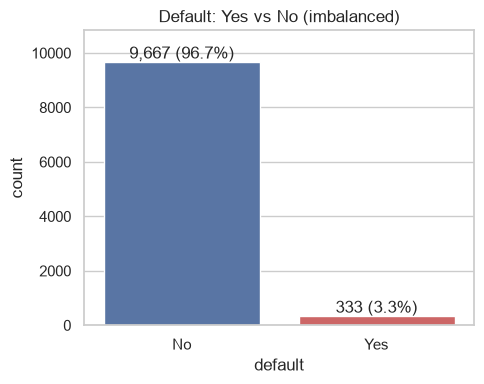

In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=df, x="default", hue="default", palette=PALETTE, legend=False, ax=ax)
for container in ax.containers:
    ax.bar_label(container, labels=[f"{v:,.0f} ({v / len(df):.1%})" for v in container.datavalues])
ax.margins(y=0.12)
ax.set_title("Default: Yes vs No (imbalanced)")
fig.tight_layout()
fig.savefig(FIG_DIR / "01_target_distribution.png", dpi=150)
plt.show()

**How to read:** each bar is a group of customers. The number on top is the count and its share.
**Look for:** the red "Yes" bar is tiny – only 3.3% default.

**วิธีอ่าน:** แท่งแต่ละแท่งคือกลุ่มลูกค้า ตัวเลขบนแท่งคือจำนวนคนและสัดส่วน
**สังเกต:** แท่งสีแดง "Yes" (ผิดนัด) เล็กมาก มีแค่ 3.3%

**Insight:** only **333 of 10,000 (3.3%)** customers default. The data is heavily imbalanced – a model that always says "No" is already 96.7% accurate, so later we must judge models by **recall / precision / AUC**, not accuracy.

**ข้อค้นพบ:** ลูกค้าผิดนัดแค่ **333 จาก 10,000 คน (3.3%)** ข้อมูลไม่สมดุลมาก โมเดลที่ตอบ "ไม่ผิดนัด" ทุกครั้งก็ถูกแล้ว 96.7% จึงต้องวัดผลโมเดลด้วย **recall / precision / AUC** ไม่ใช่ความแม่นยำ (accuracy)

## 3. Defaulters vs non-defaulters / คนผิดนัด เทียบกับ คนไม่ผิดนัด

In [6]:
run("summary_by_default")

```sql
SELECT
    default_flag,
    COUNT(*)                     AS n,
    ROUND(AVG(balance), 1)       AS avg_balance,
    ROUND(MEDIAN(balance), 1)    AS median_balance,
    ROUND(AVG(income), 0)        AS avg_income,
    ROUND(MEDIAN(income), 0)     AS median_income,
    ROUND(100 * AVG(is_student), 1) AS pct_student
FROM default_clean
GROUP BY default_flag
ORDER BY default_flag;
```

,default_flag,n,avg_balance,median_balance,avg_income,median_income,pct_student
0,0,9667,803.9,802.9,33566.0,34589.0,29.1
1,1,333,1747.8,1789.1,32089.0,31515.0,38.1


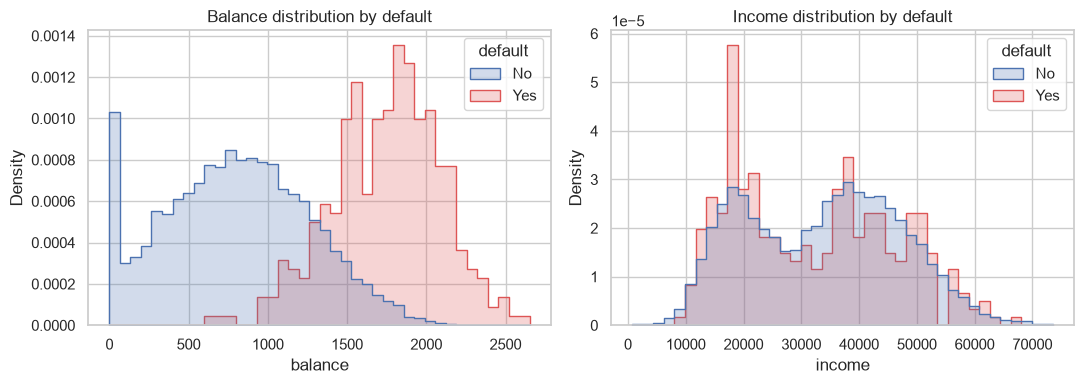

In [7]:
# Density (not count) so the small "Yes" group is visible next to the big "No" group
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col in zip(axes, ["balance", "income"]):
    sns.histplot(data=df, x=col, hue="default", palette=PALETTE, stat="density",
                 common_norm=False, element="step", bins=40, ax=ax)
    ax.set_title(f"{col.title()} distribution by default")
fig.tight_layout()
fig.savefig(FIG_DIR / "02_distributions_by_default.png", dpi=150)
plt.show()

**How to read:** the bottom axis is the amount. The higher the line, the more customers have that amount. Blue = did not default, red = defaulted. Each colour is scaled to its own group, so the small red group is easy to see.
**Look for:** left chart – red sits far to the right (higher balance). Right chart – red and blue overlap (income is similar).

**วิธีอ่าน:** แกนนอนคือจำนวนเงิน เส้นยิ่งสูง แปลว่ามีลูกค้าที่มียอดนั้นมาก สีน้ำเงิน = ไม่ผิดนัด สีแดง = ผิดนัด (แต่ละสีปรับสเกลตามกลุ่มของตัวเอง จึงเห็นกลุ่มสีแดงที่มีน้อยได้ชัด)
**สังเกต:** กราฟซ้าย – สีแดงอยู่ทางขวา (ยอดหนี้สูงกว่า) กราฟขวา – สีแดงกับสีน้ำเงินซ้อนกัน (รายได้พอๆ กัน)

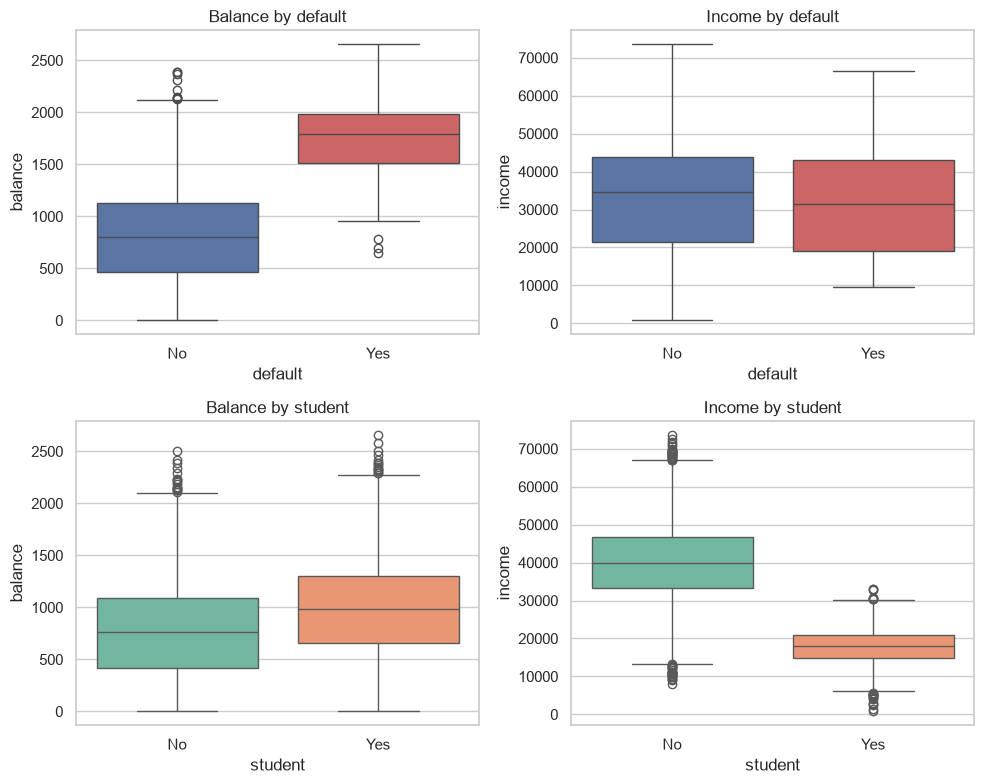

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for row, group in enumerate(["default", "student"]):
    for col_idx, col in enumerate(["balance", "income"]):
        ax = axes[row, col_idx]
        sns.boxplot(data=df, x=group, y=col, hue=group, legend=False, ax=ax,
                    palette=PALETTE if group == "default" else "Set2")
        ax.set_title(f"{col.title()} by {group}")
fig.tight_layout()
fig.savefig(FIG_DIR / "03_boxplots.png", dpi=150)
plt.show()

**How to read:** each box holds the middle 50% of customers. The line inside is the median (middle value). Dots are unusual values.
**Look for:** top-left – the defaulters' box is much higher (more balance). Bottom-right – students earn much less.

**วิธีอ่าน:** กล่องคือลูกค้ากลุ่มกลาง 50% เส้นในกล่องคือค่ากลาง (median) จุดคือค่าที่ผิดปกติ
**สังเกต:** มุมซ้ายบน – กล่องของคนผิดนัดอยู่สูงกว่ามาก (ยอดหนี้มากกว่า) มุมขวาล่าง – นักศึกษามีรายได้ต่ำกว่ามาก

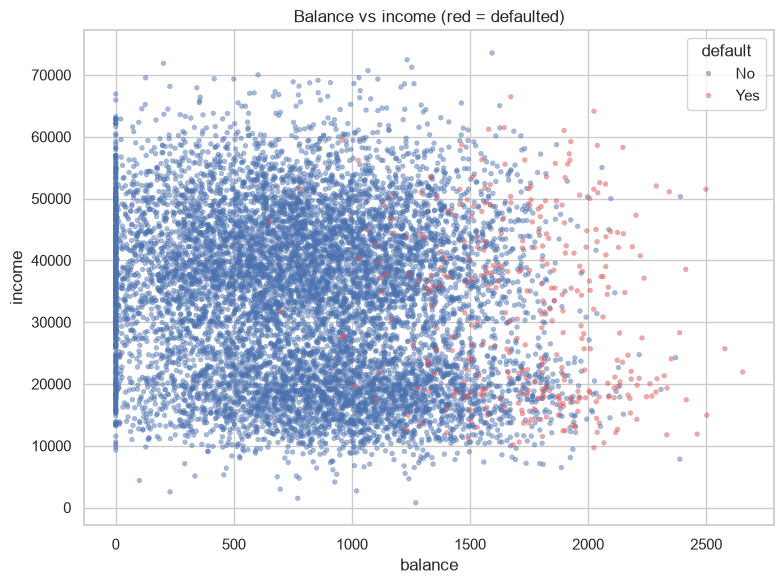

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=df.sort_values("default_flag"), x="balance", y="income", hue="default",
                palette=PALETTE, alpha=0.5, s=12, edgecolor=None, ax=ax)
ax.set_title("Balance vs income (red = defaulted)")
fig.tight_layout()
fig.savefig(FIG_DIR / "04_scatter_balance_income.png", dpi=150)
plt.show()

**How to read:** each dot is one customer. Left–right = balance, up–down = income. Red = defaulted.
**Look for:** red dots sit on the right at every height → balance matters, income does not.

**วิธีอ่าน:** จุด 1 จุด = ลูกค้า 1 คน แนวนอน = ยอดหนี้ แนวตั้ง = รายได้ สีแดง = ผิดนัด
**สังเกต:** จุดสีแดงอยู่ทางขวาในทุกระดับความสูง → ยอดหนี้มีผล แต่รายได้ไม่มีผล

**Insight:**
- Defaulters carry about **2× the balance** (avg ~1,748 vs ~804). The two balance distributions barely overlap.
- **Income looks almost the same** for both groups (~32k vs ~34k).
- In the scatter plot, red points sit on the **right side (high balance)** at every income level → balance separates the groups, income does not.

**ข้อค้นพบ:**
- คนที่ผิดนัดมียอดหนี้ประมาณ **2 เท่า** ของคนที่ไม่ผิดนัด (เฉลี่ย ~1,748 เทียบกับ ~804)
- **รายได้แทบไม่ต่างกัน** (~32k เทียบกับ ~34k)
- ในกราฟจุด สีแดงอยู่ **ทางขวา (ยอดหนี้สูง)** ในทุกระดับรายได้ → **ยอดหนี้** แยกคนเสี่ยงออกได้ แต่ **รายได้** แยกไม่ได้

## 4. Balance: where does risk start? / ยอดหนี้: ความเสี่ยงเริ่มตรงไหน?

In [10]:
band = run("default_rate_by_balance_band")
band

```sql
SELECT
    CAST(FLOOR(balance / 500) * 500 AS INTEGER)       AS balance_from,
    CAST(FLOOR(balance / 500) * 500 + 500 AS INTEGER) AS balance_to,
    COUNT(*)                                          AS n,
    CAST(SUM(default_flag) AS INTEGER)                AS n_default,
    ROUND(100 * AVG(default_flag), 2)                 AS default_rate_pct
FROM default_clean
GROUP BY balance_from, balance_to
ORDER BY balance_from;
```

,balance_from,balance_to,n,n_default,default_rate_pct
0,0,500,2613,0,0.00
1,500,1000,3755,6,0.16
2,1000,1500,2721,69,2.54
3,1500,2000,805,177,21.99
4,2000,2500,103,78,75.73
5,2500,3000,3,3,100.00


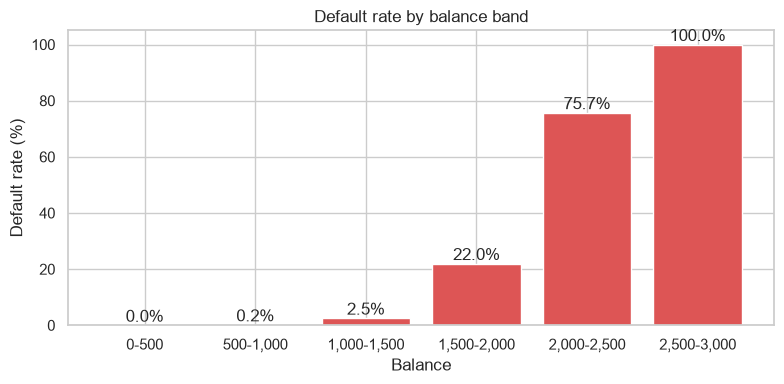

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
labels = [f"{a:,}-{b:,}" for a, b in zip(band["balance_from"], band["balance_to"])]
bars = ax.bar(labels, band["default_rate_pct"], color="#DD5555")
ax.bar_label(bars, labels=[f"{v:.1f}%" for v in band["default_rate_pct"]])
ax.set(title="Default rate by balance band", xlabel="Balance", ylabel="Default rate (%)")
fig.tight_layout()
fig.savefig(FIG_DIR / "05_default_rate_by_balance.png", dpi=150)
plt.show()

**How to read:** each bar is a balance range. Its height is the % of customers in that range who defaulted.
**Look for:** almost 0% below 1,000, then a sharp jump.

**วิธีอ่าน:** แท่งแต่ละแท่งคือช่วงยอดหนี้ ความสูงคือ % ของลูกค้าในช่วงนั้นที่ผิดนัด
**สังเกต:** ต่ำกว่า 1,000 แทบไม่มีใครผิดนัด หลังจากนั้นพุ่งขึ้นเร็วมาก

**Insight:** risk is almost zero below 1,000, then climbs very fast: **2.5% → 22% → 76%** in the next three bands. This S-shaped jump is exactly what **logistic regression** is built for.

(The 2,500+ band shows 100%, but it has only 3 customers – too few to trust.)

**ข้อค้นพบ:** ยอดหนี้ต่ำกว่า 1,000 ความเสี่ยงเกือบเป็นศูนย์ แล้วเพิ่มเร็วมาก: **2.5% → 22% → 76%** ในสามช่วงถัดไป รูปแบบกราฟตัว S แบบนี้เหมาะกับโมเดล **logistic regression** พอดี (ช่วง 2,500+ ที่ขึ้น 100% มีลูกค้าแค่ 3 คน น้อยเกินไปที่จะเชื่อถือได้)

## 5. Income: does it matter? / รายได้มีผลไหม?

In [12]:
run("default_rate_by_income_band")

```sql
SELECT
    CAST(FLOOR(income / 10000) * 10000 AS INTEGER) AS income_from,
    COUNT(*)                                       AS n,
    CAST(SUM(default_flag) AS INTEGER)             AS n_default,
    ROUND(100 * AVG(default_flag), 2)              AS default_rate_pct
FROM default_clean
GROUP BY income_from
ORDER BY income_from;
```

,income_from,n,n_default,default_rate_pct
0,0,110,1,0.91
1,10000,2052,92,4.48
2,20000,1876,65,3.46
3,30000,2465,70,2.84
4,40000,2361,64,2.71
5,50000,977,36,3.68
6,60000,153,5,3.27
7,70000,6,0,0.00


**Insight:** the default rate stays around **3–4.5% in every income band** – no clear pattern. Income on its own is a weak predictor. (The 10k–20k band is a bit higher, but **92% of that band are students** – see next section.)

**ข้อค้นพบ:** อัตราผิดนัดอยู่ที่ประมาณ **3–4.5% ในทุกช่วงรายได้** ไม่มีรูปแบบชัดเจน รายได้อย่างเดียวจึงช่วยทำนายได้น้อย (ช่วง 10k–20k สูงกว่านิดหน่อย แต่ **92% ของช่วงนี้เป็นนักศึกษา** – ดูหัวข้อถัดไป)

## 6. Students and the "student paradox" / นักศึกษา และ "student paradox"

In [13]:
run("summary_by_student")

```sql
SELECT
    is_student,
    COUNT(*)                          AS n,
    CAST(SUM(default_flag) AS INTEGER) AS n_default,
    ROUND(100 * AVG(default_flag), 2) AS default_rate_pct,
    ROUND(AVG(balance), 0)            AS avg_balance,
    ROUND(AVG(income), 0)             AS avg_income
FROM default_clean
GROUP BY is_student
ORDER BY is_student;
```

,is_student,n,n_default,default_rate_pct,avg_balance,avg_income
0,0,7056,206,2.92,772.0,40012.0
1,1,2944,127,4.31,988.0,17950.0


Overall, students default **more** (4.31% vs 2.92%). But students also carry **higher balances** (988 vs 772). Is being a student risky, or is it just the balance? Compare students and non-students **at the same balance level**:

โดยรวมนักศึกษาผิดนัด **มากกว่า** (4.31% เทียบกับ 2.92%) แต่นักศึกษาก็มี **ยอดหนี้สูงกว่า** ด้วย (988 เทียบกับ 772) ความเสี่ยงมาจากการเป็นนักศึกษา หรือมาจากยอดหนี้? ลองเทียบนักศึกษากับคนทั่วไป **ที่ยอดหนี้ระดับเดียวกัน**:

In [14]:
paradox = run("student_paradox")
paradox

```sql
-- Same balance band, student vs non-student default rate.
SELECT
    CAST(FLOOR(balance / 500) * 500 AS INTEGER) AS balance_from,
    COUNT(*) FILTER (WHERE is_student = 0)      AS n_non_student,
    COUNT(*) FILTER (WHERE is_student = 1)      AS n_student,
    ROUND(100 * AVG(default_flag) FILTER (WHERE is_student = 0), 2) AS non_student_rate_pct,
    ROUND(100 * AVG(default_flag) FILTER (WHERE is_student = 1), 2) AS student_rate_pct
FROM default_clean
GROUP BY balance_from
ORDER BY balance_from;
```

,balance_from,n_non_student,n_student,non_student_rate_pct,student_rate_pct
0,0,2140,473,0.00,0.00
1,500,2709,1046,0.22,0.00
2,1000,1720,1001,2.91,1.90
3,1500,444,361,25.68,17.45
4,2000,43,60,83.72,70.00
5,2500,0,3,NaN,100.00


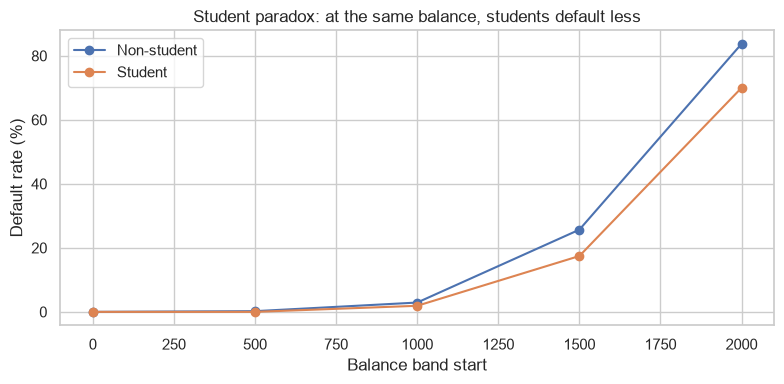

In [15]:
plot_df = paradox.copy()
# Rates from fewer than 10 people are noise (e.g. 3 students at 2500+)
plot_df.loc[plot_df["n_non_student"] < 10, "non_student_rate_pct"] = None
plot_df.loc[plot_df["n_student"] < 10, "student_rate_pct"] = None

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(plot_df["balance_from"], plot_df["non_student_rate_pct"], marker="o", label="Non-student")
ax.plot(plot_df["balance_from"], plot_df["student_rate_pct"], marker="o", label="Student")
ax.set(title="Student paradox: at the same balance, students default less",
       xlabel="Balance band start", ylabel="Default rate (%)")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "06_student_paradox.png", dpi=150)
plt.show()

**How to read:** each point is the default rate for one balance range. Blue line = non-students, orange line = students.
**Look for:** the orange line is always **below** the blue line → at the same balance, students default less.

**วิธีอ่าน:** แต่ละจุดคืออัตราผิดนัดของช่วงยอดหนี้หนึ่งช่วง เส้นสีน้ำเงิน = ไม่ใช่นักศึกษา เส้นสีส้ม = นักศึกษา
**สังเกต:** เส้นสีส้มอยู่ **ต่ำกว่า** เส้นสีน้ำเงินเสมอ → ที่ยอดหนี้เท่ากัน นักศึกษาผิดนัดน้อยกว่า

**Insight – Simpson's paradox:** in every balance band, students default **less** than non-students (e.g. 1,500–2,000: **17.5% vs 25.7%**). Students only *look* riskier overall because more of them have high balances.

**Why it matters:** a model must include `balance` together with `is_student`. Looking at student status alone gives the wrong direction.

**ข้อค้นพบ – Simpson's paradox (ความขัดแย้งของซิมป์สัน):** ในทุกช่วงยอดหนี้ นักศึกษาผิดนัด **น้อยกว่า** คนทั่วไป (เช่น ช่วง 1,500–2,000: **17.5% เทียบกับ 25.7%**) นักศึกษา *ดู* เสี่ยงกว่าในภาพรวม เพียงเพราะมีคนยอดหนี้สูงมากกว่า

**ทำไมสำคัญ:** โมเดลต้องใช้ `balance` คู่กับ `is_student` เสมอ ถ้าดูแค่สถานะนักศึกษาอย่างเดียวจะได้ข้อสรุปผิดทิศ

## 7. Zero-balance customers and correlations / ลูกค้ายอดหนี้ 0 และความสัมพันธ์ระหว่างคอลัมน์

In [16]:
run("zero_balance")

```sql
SELECT
    COUNT(*)                           AS n_zero_balance,
    CAST(SUM(default_flag) AS INTEGER) AS n_default,
    CAST(SUM(is_student) AS INTEGER)   AS n_student
FROM default_clean
WHERE balance = 0;
```

,n_zero_balance,n_default,n_student
0,499,0,66


In [17]:
run("correlations")

```sql
SELECT
    ROUND(CORR(balance, default_flag), 3)    AS balance_vs_default,
    ROUND(CORR(income, default_flag), 3)     AS income_vs_default,
    ROUND(CORR(is_student, default_flag), 3) AS student_vs_default,
    ROUND(CORR(balance, income), 3)          AS balance_vs_income,
    ROUND(CORR(is_student, balance), 3)      AS student_vs_balance,
    ROUND(CORR(is_student, income), 3)       AS student_vs_income
FROM default_clean;
```

,balance_vs_default,income_vs_default,student_vs_default,balance_vs_income,student_vs_balance,student_vs_income
0,0.35,-0.02,0.035,-0.152,0.204,-0.754


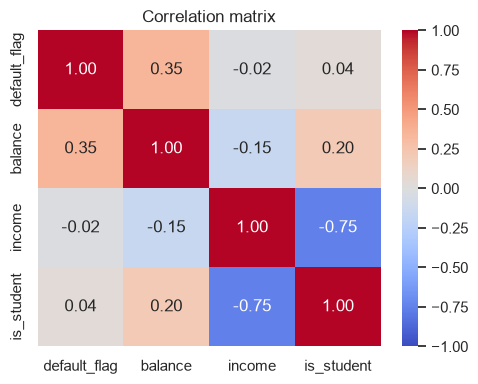

In [18]:
fig, ax = plt.subplots(figsize=(5, 4))
corr = df[["default_flag", "balance", "income", "is_student"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation matrix")
fig.tight_layout()
fig.savefig(FIG_DIR / "07_correlation_heatmap.png", dpi=150)
plt.show()

**How to read:** each square shows how strongly two columns move together, from −1 (opposite directions) to +1 (same direction). 0 = no link. Stronger colour = stronger link.
**Look for:** `balance` vs `default_flag` = **0.35** (the strongest link to default). `is_student` vs `income` = **−0.75** (students earn less).

**วิธีอ่าน:** แต่ละช่องบอกว่าสองคอลัมน์ขยับไปด้วยกันแค่ไหน ตั้งแต่ −1 (สวนทางกัน) ถึง +1 (ไปทางเดียวกัน) 0 = ไม่สัมพันธ์กัน สียิ่งเข้มยิ่งสัมพันธ์มาก
**สังเกต:** `balance` กับ `default_flag` = **0.35** (สัมพันธ์กับการผิดนัดมากที่สุด) `is_student` กับ `income` = **−0.75** (นักศึกษารายได้น้อยกว่า)

**Insight:**
- **499 customers have a balance of 0, and none of them default.** This is a valid group, not an error, so we keep them.
- `balance` has the strongest link with default (**0.35**). `income` has almost none (**−0.02**).
- `is_student` and `income` are strongly linked (**−0.75**): students earn much less. Using both in a model repeats much of the same information (**multicollinearity**).

**ข้อค้นพบ:**
- **ลูกค้า 499 คนมียอดหนี้ 0 และไม่มีใครผิดนัดเลย** เป็นกลุ่มปกติ ไม่ใช่ข้อมูลผิด จึงเก็บไว้
- `balance` สัมพันธ์กับการผิดนัดมากที่สุด (**0.35**) ส่วน `income` แทบไม่สัมพันธ์ (**−0.02**)
- `is_student` กับ `income` สัมพันธ์กันสูง (**−0.75**) นักศึกษารายได้น้อยกว่ามาก ถ้าใช้ทั้งคู่ในโมเดลจะเป็นข้อมูลซ้ำซ้อน (**multicollinearity**)

## 8. Summary – what EDA tells us for modeling / สรุป – EDA บอกอะไรสำหรับการสร้างโมเดล

| # | Finding | What to do in the model |
|---|---|---|
| 1 | Only 3.3% default (imbalanced) | Judge by recall / precision / AUC, and tune the cutoff (e.g. 0.2 instead of 0.5) |
| 2 | `balance` is the strongest predictor, with an S-shaped jump after ~1,000 | Use logistic regression; `balance` must be in the model |
| 3 | `income` barely changes default rate | Probably drop it, or test whether it helps |
| 4 | Student paradox: riskier overall, safer at the same balance | Always use `is_student` together with `balance` |
| 5 | `is_student` and `income` are strongly correlated (−0.75) | Avoid using both; keep `is_student` |
| 6 | 499 zero-balance customers, 0 defaults | Keep them – valid, very low-risk group |

**สรุปภาษาไทย**

| # | สิ่งที่พบ | สิ่งที่ควรทำในโมเดล |
|---|---|---|
| 1 | ผิดนัดแค่ 3.3% (ข้อมูลไม่สมดุล) | วัดผลด้วย recall / precision / AUC และปรับเกณฑ์ตัดสิน (เช่น 0.2 แทน 0.5) |
| 2 | **ยอดหนี้** ทำนายได้ดีที่สุด ความเสี่ยงพุ่งแบบตัว S หลัง ~1,000 | ใช้ logistic regression และต้องมี `balance` ในโมเดล |
| 3 | **รายได้** แทบไม่เปลี่ยนอัตราผิดนัด | น่าจะตัดออก หรือทดสอบว่าช่วยไหม |
| 4 | Student paradox: ภาพรวมดูเสี่ยงกว่า แต่ปลอดภัยกว่าที่ยอดหนี้เท่ากัน | ใช้ `is_student` คู่กับ `balance` เสมอ |
| 5 | `is_student` กับ `income` สัมพันธ์กันสูง (−0.75) | ไม่ใช้ทั้งคู่ เลือกเก็บ `is_student` |
| 6 | ลูกค้ายอดหนี้ 0 มี 499 คน ไม่มีใครผิดนัด | เก็บไว้ เป็นกลุ่มปกติที่เสี่ยงต่ำมาก |